<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F01_bigquery_native_sql.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 01 · Serverless BigQuery ML Forecasting (`ARIMA_PLUS` & `TimesFM`)

Execute enterprise time-series forecasting directly inside Google Cloud's serverless data warehouse using **pure BigQuery SQL** — comparing classical state-space decomposition (`ML.FORECAST` with `ARIMA_PLUS`) against zero-shot foundation model inference (`AI.FORECAST` with Google Research's **TimesFM 2.0**) and blending both into a consensus ensemble.

> [!NOTE]
> **Why Both `arima_plus` and `timesfm` Are Per-Series (`local`) Models:**
> Even though BigQuery executes all series in a single vectorized SQL query (`TIME_SERIES_ID_COL='ts_id'` or `id_cols=['ts_id']`), each series is forecast in mathematical isolation with zero cross-series parameter sharing (`supports_global = False`). All 21 evaluation metrics are scored by the exact same Python metric engine (`metrics.compute_metrics`) used by Spark, Ray, Vertex, and GCE.

```mermaid
flowchart LR
    subgraph Source["BigQuery / BigLake Iceberg"]
        S1["source_series_native<br/>or source_series_iceberg"]
    end
    subgraph NativeEngine["engines/bigquery_engine.py (Serverless SQL)"]
        A1["arima_plus<br/>CREATE MODEL ... ARIMA_PLUS<br/>+ ML.FORECAST"]
        T1["timesfm<br/>AI.FORECAST(model => TimesFM 2.0)"]
        SCORE["_score_fold()<br/>Identical 21-Metric Panel"]
    end
    subgraph Ens["ensemble_run.py"]
        E1["combine_calculated() · fit_learned()<br/>mean · inverse_error · nnls"]
    end
    S1 --> A1 & T1 --> SCORE --> E1 --> REG["v_model_leaderboard"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Configure the Native SQL Run & Explain the Execution Plan

We configure both BigQuery-native models (`arima_plus`, `timesfm`) with a 2-fold rolling-origin backtest and in-run ensembling (`mean`, `inverse_error`, `nnls`). Calling `forecaster.explain()` validates the configuration and prints the per-family execution plan before any query is submitted.

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb01 bq native {int(time.time())}"
SOURCE_TABLE = "source_series_native"  # flip to "source_series_iceberg" to read BigLake Iceberg
MODELS = ["arima_plus", "timesfm"]
HORIZON = 28
SERIES_LIMIT = 50
N_FOLDS = 2
ENSEMBLE_STRATEGIES = ["mean", "inverse_error", "nnls"]
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ENSEMBLE_STRATEGIES},
)

forecaster = Forecaster(cfg, settings=settings)
print("Deterministic run_id:", forecaster.run_id)
display(forecaster.explain())  # pass validate_data=True to also run BigQuery pre-flight table checks

Deterministic run_id: nb01-bq-native-1791144909-1c0312750f39


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb01-bq-native-1791144909-1c0312750f39,native,sf-nb01-bq-native-1791144909-1c0312750f39-nati...,bigquery,sql,1,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",50,2,100,none,
1,nb01-bq-native-1791144909-1c0312750f39,ensemble,sf-nb01-bq-native-1791144909-1c0312750f39-ense...,bigquery,sql,1,sql,None,"ensemble_mean, ensemble_inverse_error, ensembl...",barrier,50,2,150,none,sf-nb01-bq-native-1791144909-1c0312750f39-nati...


## Act 3 · Launch & Monitor Live (`forecaster.run_live()`)

`forecaster.run_live()` launches `forecaster.run()` on a background daemon thread, renders a live in-place progress dashboard via `forecaster.monitor()`, and returns the completed `RunResult`.

Run nb01-bq-native-1791144909-1c0312750f39 finished with status=COMPLETED in 294.2s


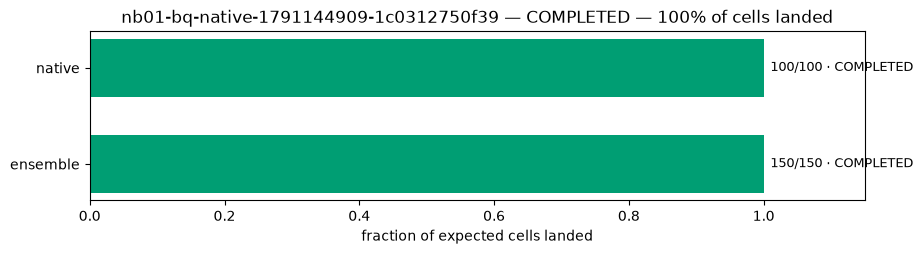

In [4]:
result = forecaster.run_live(poll_s=10.0, probe=True)
print(f"Run {result.run_id} finished with status={result.status} in {result.runtime_seconds:.1f}s")

## Act 4 · Retrieve & Review Results (Leaderboard, Distributions & Forecast Fan Charts)

With the run complete, we inspect:
1. **`forecaster.leaderboard_df()`:** Ranked model + ensemble table from `v_model_leaderboard`.
2. **`plot_leaderboard()` & `plot_metric_distribution()`:** Visual ranking and per-series error quantiles (`p10`/`p50`/`p90`).
3. **`forecaster.plot_forecasts()`:** Historical series + backtest OOF overlay + 80% prediction intervals.
4. **`forecaster.trace()` & `plot_trace()`:** Execution timeline across families.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,timesfm,native,False,None,bigquery,50,wape,0.340320,0.113621,...,10.297393,16.223770,0.805357,52.509439,None,None,1.0,1400,NaN,NaN
1,2,ensemble_nnls,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.345019,0.112429,...,10.190176,15.967542,NaN,NaN,None,None,0.0,1400,-0.004699,-0.013807
2,3,ensemble_inverse_error,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.348702,0.113523,...,10.232083,15.878738,NaN,NaN,None,None,1.0,1400,-0.008382,-0.024630
3,4,ensemble_mean,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.352697,0.113143,...,10.292932,15.960779,NaN,NaN,None,None,1.0,1400,-0.012377,-0.036369
4,5,arima_plus,native,False,None,bigquery,50,wape,0.373395,0.119310,...,10.901924,16.608170,0.594643,60.643406,None,None,1.0,1400,NaN,NaN


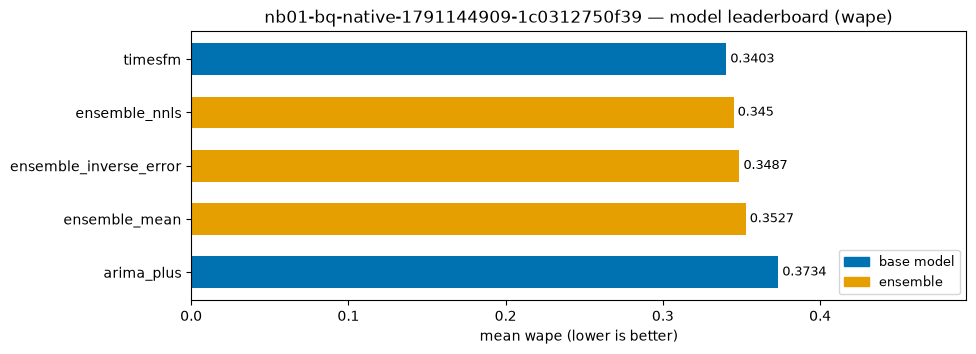

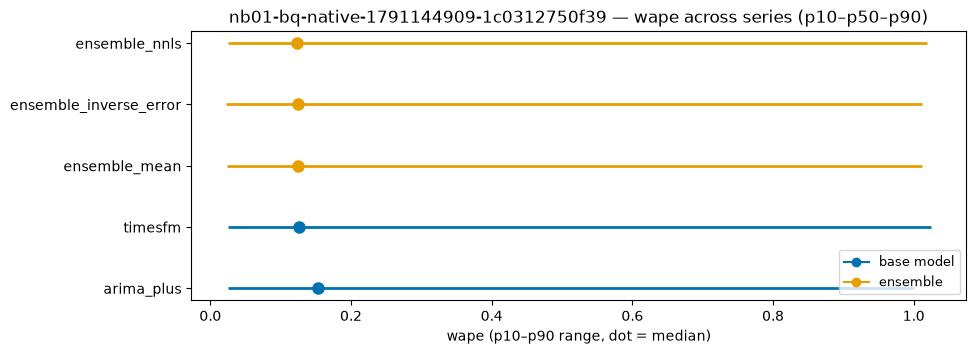

In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard, plot_metric_distribution, plot_trace

lb_df = forecaster.leaderboard_df()
display(lb_df)

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

plot_metric_distribution(review)
plt.show()

Plotting forecasts for series: s_000000


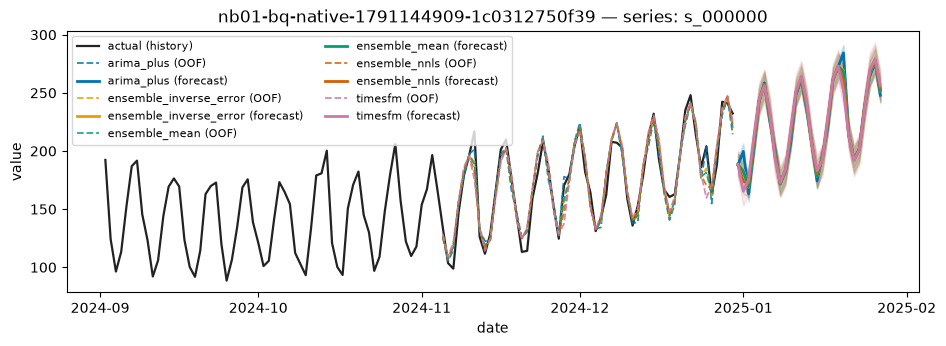

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,ensemble,ensemble,2026-10-04 20:19:34.004777+00:00,2026-10-04 20:19:49.385954+00:00,15.381177,COMPLETED,bigquery,None,None
1,job,native,native,2026-10-04 20:15:55.012844+00:00,2026-10-04 20:19:29.252466+00:00,214.239622,COMPLETED,bigquery,None,None


In [6]:
# Inspect forecast fan chart + backtest OOF overlay on a single series
preds_df = forecaster.predictions_df(include_history=True, include_oof=True, series_limit=1)
sample_ts = str(preds_df["ts_id"].iloc[0])
print(f"Plotting forecasts for series: {sample_ts}")
forecaster.plot_forecasts(ts_id=sample_ts, history_tail=120)
plt.show()

# Inspect family execution trace
trace_df = forecaster.trace()
display(trace_df)

## Act 5 · Deep Dive: Full 21-Metric Panel, Conformal Interval Calibration & Forecast Decomposition

1. Passing `all_metrics=True` to `forecaster.leaderboard_df()` returns all **21 evaluation metrics** (`mean_mae`, `mean_rmse`, `mean_wape`, `mean_mase`, `mean_rmsse`, `mean_coverage`, `mean_interval_score`, `mean_msis`, `mean_r2`, `mean_cv`, ...).
2. `forecaster.calibration_df(by='horizon')` and `forecaster.plot_calibration()` compare empirical 80% interval coverage and interval width across lead steps $h = 1 \dots H$.
3. `forecaster.plot_forecast_explanation()` decomposes a single series' historical trajectory, OOF backtest predictions, and future forecast into Trend + Regime Level Shift, Weekly Seasonality, and Residual Uncertainty.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_rmsle,p50_rmsle,mean_msse,p50_msse,mean_msis,p50_msis,mean_r2,p50_r2,mean_cv,p50_cv
0,1,timesfm,native,False,None,bigquery,50,wape,0.340320,0.113621,...,0.360714,0.110180,0.551061,0.512206,3.419077,3.364808,0.173323,0.052193,0.525110,0.316577
1,2,ensemble_nnls,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.345019,0.112429,...,0.418777,0.146165,0.534066,0.483507,NaN,NaN,0.199330,0.078295,0.513666,0.313267
2,3,ensemble_inverse_error,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.348702,0.113523,...,0.419704,0.147431,0.530231,0.481931,NaN,NaN,0.202582,0.013267,0.508800,0.310985
3,4,ensemble_mean,ensemble,True,fdbc4b03f8ab,ensemble,50,wape,0.352697,0.113143,...,0.424124,0.147900,0.532302,0.481964,NaN,NaN,0.194226,-0.007561,0.508901,0.311103
4,5,arima_plus,native,False,None,bigquery,50,wape,0.373395,0.119310,...,0.498987,0.188155,0.573802,0.487223,4.314802,3.992049,0.091418,-0.045537,0.519708,0.310125


,model_type,horizon_step,n,coverage,nominal_coverage,coverage_error,mean_width
0,arima_plus,1,100,0.59,0.8,-0.21,17.257735
1,arima_plus,2,100,0.64,0.8,-0.16,19.874276
2,arima_plus,3,100,0.58,0.8,-0.22,21.024663
3,arima_plus,4,100,0.58,0.8,-0.22,21.653820
4,arima_plus,5,100,0.68,0.8,-0.12,22.040536
5,arima_plus,6,100,0.61,0.8,-0.19,22.296021
6,arima_plus,7,100,0.51,0.8,-0.29,22.472980
7,arima_plus,8,100,0.69,0.8,-0.11,22.599547
8,arima_plus,9,100,0.58,0.8,-0.22,22.692148
9,arima_plus,10,100,0.59,0.8,-0.21,22.761045


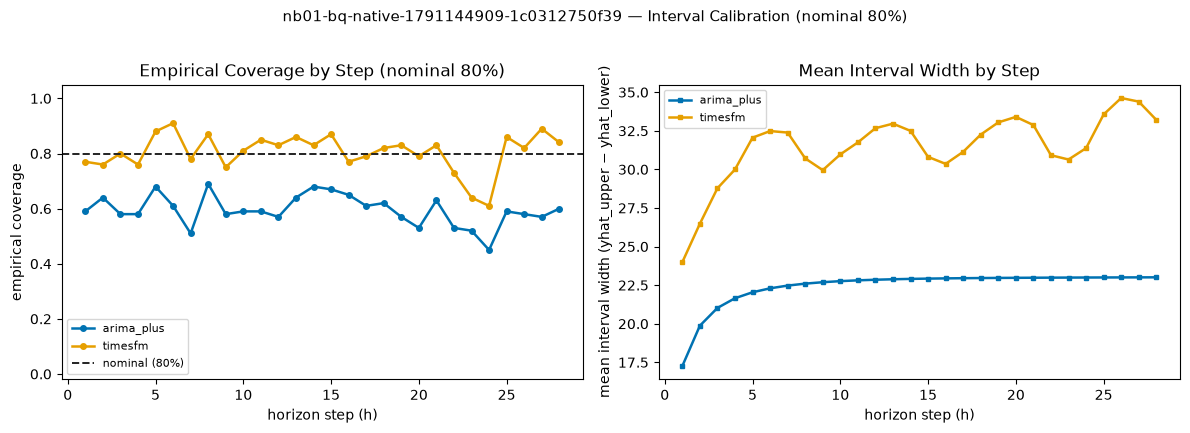

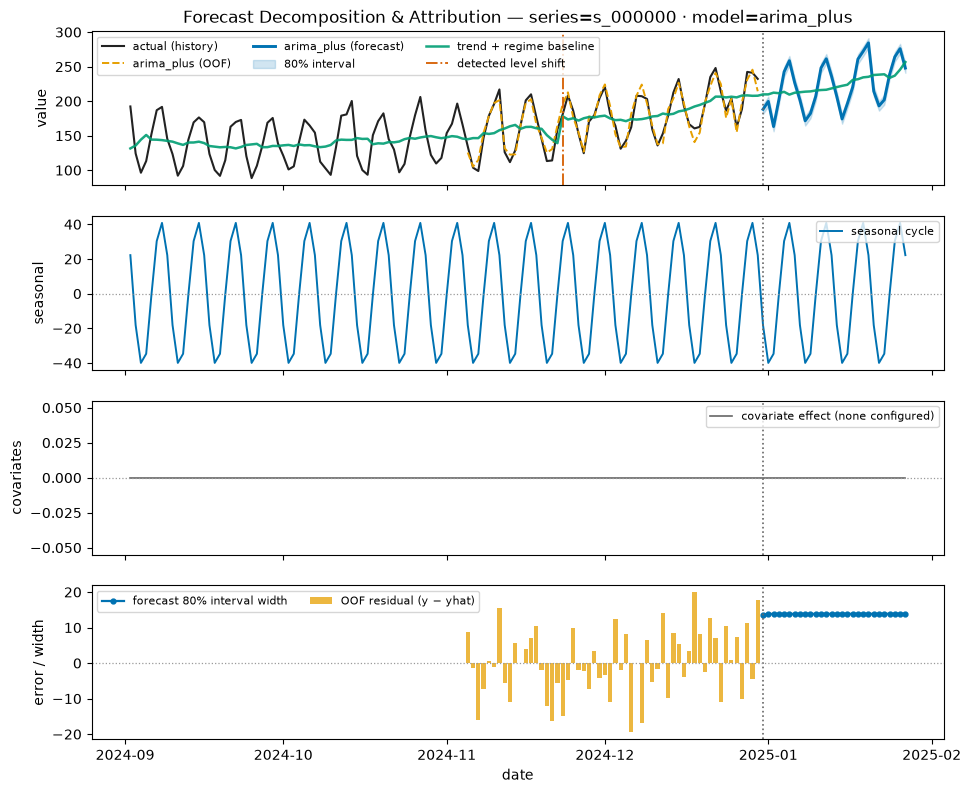

In [7]:
full_lb = forecaster.leaderboard_df(all_metrics=True)
display(full_lb)

display(forecaster.calibration_df(by="horizon").head(10))
forecaster.plot_calibration()
plt.show()

forecaster.plot_forecast_explanation(ts_id=sample_ts, history_tail=120)
plt.show()